In [3]:
import os
import sys

# Move up one directory to the project root and add it to the Python path
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Now your imports will work perfectly!
from src.data_loader import load_insurance_data, calculate_insurance_metrics
from src.eda_utils import get_missing_summary, plot_loss_ratio_by_dimension

In [4]:
# In your notebook cell:
from src.data_loader import load_insurance_data, calculate_insurance_metrics

# Point directly to your zipped text file path
zip_path = '../data/MachineLearningRating_v3.zip' 

df = load_insurance_data(zip_path)
df = calculate_insurance_metrics(df)

print(f"Data Successfully Ingested! Shape: {df.shape}")
print("Columns Loaded:", df.columns.tolist()[:5], "... total columns:", len(df.columns))


Data Successfully Ingested! Shape: (1000098, 54)
Columns Loaded: ['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'Citizenship'] ... total columns: 54


In [5]:
# Notebook Cell Execution
from src.data_loader import load_insurance_data, calculate_insurance_metrics
from src.eda_utils import get_missing_summary, plot_loss_ratio_by_dimension

# Point directly to your zipped text file path
zip_path = '../data/MachineLearningRating_v3.zip' 

df = load_insurance_data(zip_path)
# df = load_insurance_data('../data/insurance_data.csv')
df = calculate_insurance_metrics(df)

# Portfolio Wide Loss Ratio
portfolio_loss_ratio = df['TotalClaims'].sum() / df['TotalPremium'].sum()
print(f"Global Portfolio Loss Ratio: {portfolio_loss_ratio:.2%}")


Global Portfolio Loss Ratio: 104.77%


I.  Data Summarization - descriptive statistics for numerical features (TotalPremium, TotalClaims, etc.), and a review of dtypes to confirm categorical, date, and numerical columns are correctly typed.

Data Quality Assessment - check for missing values and document handling strategy

In [13]:
import pandas as pd
from src.data_loader import load_insurance_data, calculate_insurance_metrics

# Point directly to your zipped text file path
zip_path = '../data/MachineLearningRating_v3.zip' 

df = load_insurance_data(zip_path)
# Load your dataset (replace with your actual file path)
# df = pd.read_csv("your_insurance_data.csv")

# --- 1. DATA TYPE AUDIT ---
print("### 1. Data Type & Missing Values Summary ###\n")
# Create an audit dataframe
dtype_audit = pd.DataFrame({
    'Data Type': df.dtypes,
    'Non-Null Count': df.notnull().sum(),
    'Null Count': df.isnull().sum(),
    'Null Percentage (%)': (df.isnull().sum() / len(df) * 100).round(2),
    'Unique Values': df.nunique()
})
print(dtype_audit)
print("\n" + "="*50 + "\n")

# --- 2. DESCRIPTIVE STATISTICS (NUMERICAL) ---
print("### 2. Descriptive Statistics for Numerical Features ###\n")
# capture all standard metrics plus explicit percentiles for distribution analysis
numerical_summary = df.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
numerical_summary['skewness'] = df.skew(numeric_only=True)
numerical_summary['kurtosis'] = df.kurt(numeric_only=True)

# Formatting for readability
print(numerical_summary.round(2))

### 1. Data Type & Missing Values Summary ###

                               Data Type  Non-Null Count  Null Count  \
UnderwrittenCoverID                int64         1000098           0   
PolicyID                           int64         1000098           0   
TransactionMonth          datetime64[us]         1000098           0   
IsVATRegistered                     bool         1000098           0   
Citizenship                          str         1000098           0   
LegalType                            str         1000098           0   
Title                                str         1000098           0   
Language                             str         1000098           0   
Bank                                 str          854137      145961   
AccountType                          str          959866       40232   
MaritalStatus                        str          991839        8259   
Gender                               str          990562        9536   
Country          

In [6]:
# working through a data analysis notebook—likely focused on short-term car or property insurance data, given the mention of Gauteng (South Africa), premiums, and claims.

# These three notes outline exactly how to handle the heavy-tailed, messy nature of insurance data. Let's break down how to actually write the Python code to answer these questions in your notebook.

# 1. Portfolio Loss Ratio Distribution
# The Loss Ratio is the ultimate health metric for an insurance portfolio. It tells you how many cents of every premium dollar are being paid out as claims.

# Loss Ratio= 
# Total Premium
# Total Claims
# ​
 
# First, you need to calculate the baseline for the entire dataset, and then look at it by Province to spot the high-risk areas.

import pandas as pd

# Point directly to your zipped text file path
zip_path = '../data/MachineLearningRating_v3.zip' 

df = load_insurance_data(zip_path)

# df = pd.read_csv('your_data.csv')  # Or read_excel, etc.

# 1. Calculate the overall baseline loss ratio
total_claims = df['TotalClaims'].sum()
total_premium = df['TotalPremium'].sum()
baseline_loss_ratio = total_claims / total_premium

print(f"Overall Portfolio Baseline Loss Ratio: {baseline_loss_ratio:.2%}")


Overall Portfolio Baseline Loss Ratio: 104.77%


In [7]:

# 2. Isolate geographical risk outliers using your custom function
# Look closely at Gauteng vs. rural provinces in the resulting plot
import pandas as pd
from src.data_loader import load_insurance_data, calculate_insurance_metrics
# Point directly to your zipped text file path
zip_path = '../data/MachineLearningRating_v3.zip' 

df = load_insurance_data(zip_path)

# Replace 'TotalClaims' and 'TotalPremium' with your exact column names
df['Loss_Ratio'] = df['TotalClaims'] / df['TotalPremium']

plot_loss_ratio_by_dimension(df, 'Province')

# What to look for: If your baseline is 65%, but Gauteng is sitting at 85%, that confirms the note's hypothesis: dense urban traffic and higher accident rates in Gauteng are driving structural risk.

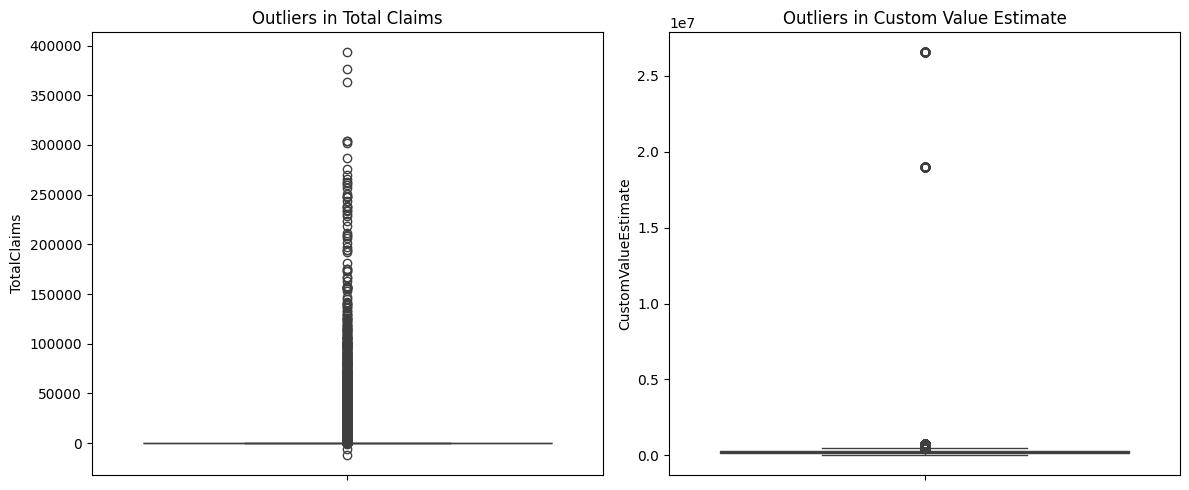

In [8]:
# 2. Financial Variable OutliersInsurance claims are notoriously heavy-tailed (log-normal). Most people claim $\$0$ or very little, but a few total-loss accidents create massive spikes. As your note says, don't drop them! Instead, let's visualize them and then fix them using the two suggested methods.Step A: Visualize the OutliersPythonimport matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

# Plot boxplots to see the extreme right tails
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, y='TotalClaims', ax=axes[0])
axes[0].set_title('Outliers in Total Claims')

sns.boxplot(data=df, y='CustomValueEstimate', ax=axes[1])
axes[1].set_title('Outliers in Custom Value Estimate')

plt.tight_layout()
plt.show()

In [9]:
# Step B: Handle the Outliers (Choose One Method)
# Depending on what your notebook requires next, you can either cap the extreme values or log-transform them.

# OPTION 1: Cap at the 99th percentile (Winsorization)
cap_claims = df['TotalClaims'].quantile(0.99)
cap_value = df['CustomValueEstimate'].quantile(0.99)

df['TotalClaims_Capped'] = df['TotalClaims'].clip(upper=cap_claims)
df['CustomValueEstimate_Capped'] = df['CustomValueEstimate'].clip(upper=cap_value)

# OPTION 2: Log Transformation (Smooths out the heavy tail for modeling)
import numpy as np

df['TotalClaims_Log'] = np.log1p(df['TotalClaims']) # log(x + 1)
df['CustomValueEstimate_Log'] = np.log1p(df['CustomValueEstimate'])

c:\Users\Almazt\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


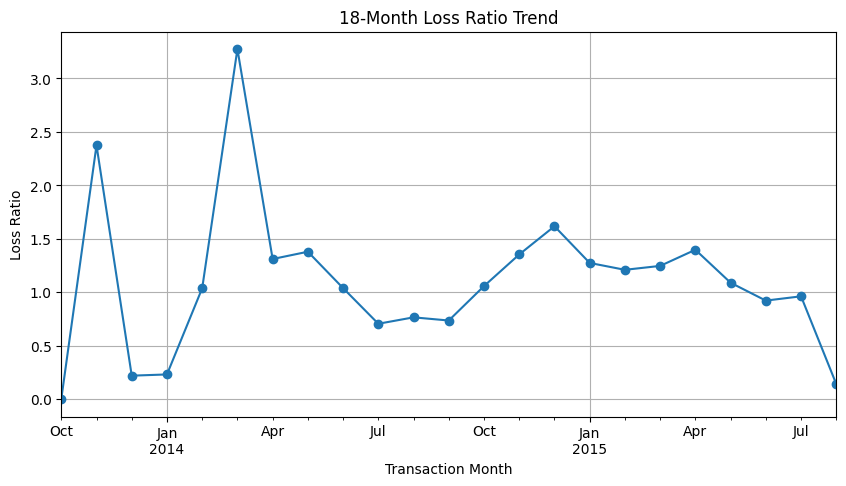

                   TotalClaims  TotalPremium  MonthlyLossRatio
TransactionMonth                                              
2013-10           0.000000e+00  3.710635e+02          0.000000
2013-11           5.058508e+04  2.130747e+04          2.374054
2013-12           9.283386e+03  4.248475e+04          0.218511
2014-01           1.243686e+04  5.408520e+04          0.229949
2014-02           6.298931e+04  6.078844e+04          1.036205
2014-03           3.227850e+05  9.857719e+04          3.274439
2014-04           3.068636e+05  2.342743e+05          1.309847
2014-05           5.180427e+05  3.759117e+05          1.378097
2014-06           5.045364e+05  4.862194e+05          1.037672
2014-07           4.289822e+05  6.092661e+05          0.704097
2014-08           6.934197e+05  9.074381e+05          0.764151
2014-09           9.089024e+05  1.237522e+06          0.734454
2014-10           1.764693e+06  1.670355e+06          1.056478
2014-11           3.794245e+06  2.805406e+06          1

In [10]:
# 3. Temporal (Time-Series) TrendsTo see if macro factors (like inflation) or seasonal trends (like summer hail storms in Gauteng) are spiking claims, you need to aggregate the data by month.Python# 1. Group dynamically by month and sum the financials
monthly_trends = df.groupby(df['TransactionMonth'].dt.to_period('M'))[['TotalClaims', 'TotalPremium']].sum()

# 2. Calculate the monthly loss ratio to see if spikes match specific months
monthly_trends['MonthlyLossRatio'] = monthly_trends['TotalClaims'] / monthly_trends['TotalPremium']

# 3. Plot the timeline to visually check for structural deviations
monthly_trends['MonthlyLossRatio'].plot(kind='line', marker='o', figsize=(10, 5))
plt.title('18-Month Loss Ratio Trend')
plt.ylabel('Loss Ratio')
plt.xlabel('Transaction Month')
plt.grid(True)
plt.show()

# Display the raw numbers
print(monthly_trends)
# What to look for: Look at the MonthlyLossRatio columns over the 18-month timeline. Is there a random, massive spike in one or two specific months? If yes, look up historical weather or economic events for that period to explain the "structural deviation."

In [11]:
# Here is a clean, robust way to write that plot_loss_ratio_by_dimension function.

# To make it truly useful for your analysis, the function will calculate the group-level loss ratios, sort them from highest risk to lowest risk, and plot a clear visual baseline so you can immediately spot which provinces are the outliers.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_loss_ratio_by_dimension(df, dimension):
    """
    Groups data by a categorical dimension, calculates the loss ratio for each group,
    and plots a sorted bar chart against the overall portfolio baseline.
    """
    # 1. Calculate the overall portfolio baseline
    overall_baseline = df['TotalClaims'].sum() / df['TotalPremium'].sum()
    
    # 2. Group by the dimension and sum the financials
    grouped = df.groupby(dimension)[['TotalClaims', 'TotalPremium']].sum()
    
    # 3. Calculate the loss ratio for each group
    grouped['LossRatio'] = grouped['TotalClaims'] / grouped['TotalPremium']
    
    # 4. Sort from highest risk to lowest risk for easier analysis
    grouped = grouped.sort_values(by='LossRatio', ascending=False).reset_index()
    
    # 5. Create the plot
    plt.figure(figsize=(10, 6))
    
    # Custom palette: highlights bars that cross the baseline
    colors = ['#d9534f' if lr > overall_baseline else '#5cb85c' for lr in grouped['LossRatio']]
    
    sns.barplot(
        data=grouped, 
        x=dimension, 
        y='LossRatio', 
        palette=colors,
        hue=dimension,  # Keeps seaborn happy
        legend=False
    )
    
    # 6. Draw the overall portfolio baseline line
    plt.axhline(
        y=overall_baseline, 
        color='black', 
        linestyle='--', 
        linewidth=2, 
        label=f'Portfolio Baseline ({overall_baseline:.1%})'
    )
    
    # 7. Formatting and labels
    plt.title(f'Loss Ratio Distribution by {dimension}', fontsize=14, pad=15)
    plt.ylabel('Loss Ratio (Claims / Premium)', fontsize=12)
    plt.xlabel(dimension, fontsize=12)
    plt.xticks(rotation=45, ha='right')
    
    # Change y-axis to percentage format for clarity
    current_values = plt.gca().get_yticks()
    plt.gca().set_yticklabels([f'{x:.0%}' for x in current_values])
    
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
    
    # Optional: return the summary dataframe for quick text inspection
    return grouped[[dimension, 'LossRatio']]

C:\Users\Almazt\AppData\Local\Temp\ipykernel_2320\653546466.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels([f'{x:.0%}' for x in current_values])


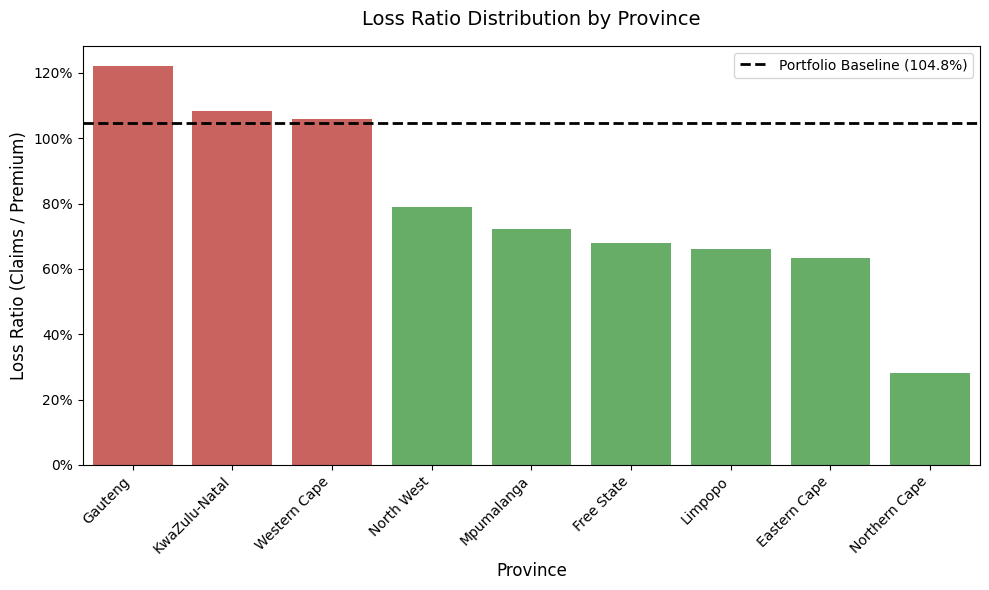

In [12]:
# How to use it:
# Once you run the block of code above to define the function, you can call it on any categorical column in your dataset:

# To answer your specific notebook question:
summary_df = plot_loss_ratio_by_dimension(df, 'Province')

# You can also use it to check other dimensions later, like VehicleType!
# plot_loss_ratio_by_dimension(df, 'VehicleType')
# Why this design works perfectly for your notebook note:
# The Sorting: Sorting the provinces from highest to lowest forces the worst "geographical risk outliers" (like Gauteng) straight to the left side of the chart.

# The Visual Cue: The bars dynamically change color. Any province with a loss ratio higher than the total portfolio baseline turns red, while safer corridors stay green.

Univariate Analysis - histograms for numerical columns and bar charts for categorical columns.

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Create a dummy dataset for demonstration
np.random.seed(42)
data = {
    "Age": np.random.normal(loc=35, scale=10, size=200).astype(int),
    "Salary": np.random.exponential(scale=50000, size=200) + 30000,
    "Department": np.random.choice(
        ["IT", "PMO", "Finance", "HR"], size=200, p=[0.4, 0.3, 0.2, 0.1]
    ),
    "Employment_Type": np.random.choice(
        ["Full-Time", "Contract"], size=200, p=[0.8, 0.2]
    ),
}
df = pd.DataFrame(data)

# 2. Automatically identify numerical and categorical columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Numerical columns: {num_cols}")
print(f"Categorical columns: {cat_cols}")

Numerical columns: ['Age', 'Salary']
Categorical columns: ['Department', 'Employment_Type']


C:\Users\Almazt\AppData\Local\Temp\ipykernel_2320\1360994095.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()


2. Plotting Numerical Columns (Histograms)
For numerical data, a histogram groups values into bins and counts how many data points fall into each bin. Adding a Kernel Density Estimate (KDE) line helps smooth out the distribution shape.

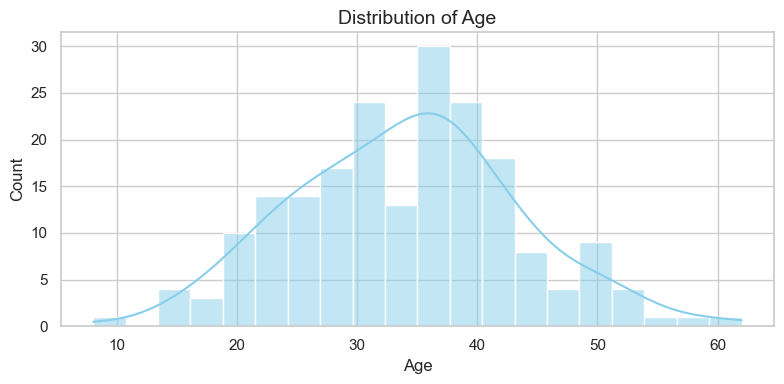

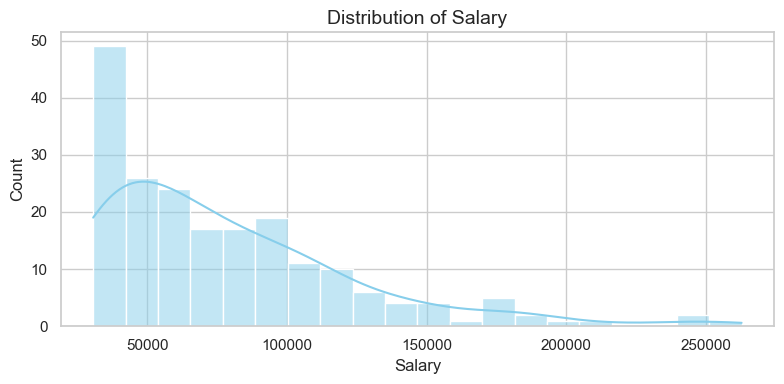

In [15]:
# Set the plotting style
sns.set_theme(style="whitegrid")

# Plot Histograms
for col in num_cols:
    plt.figure(figsize=(8, 4))
    # kde=True adds the smooth density curve over the bins
    sns.histplot(data=df, x=col, kde=True, bins=20, color="skyblue")

    plt.title(f"Distribution of {col}", fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel("Count", fontsize=12)
    plt.tight_layout()
    plt.show()

3. Plotting Categorical Columns (Bar Charts)
For categorical data, sns.countplot automatically handles the aggregation, counting the occurrences of each unique string or category and rendering them as distinct bars.

C:\Users\Almazt\AppData\Local\Temp\ipykernel_2320\1293667516.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette="Set2")


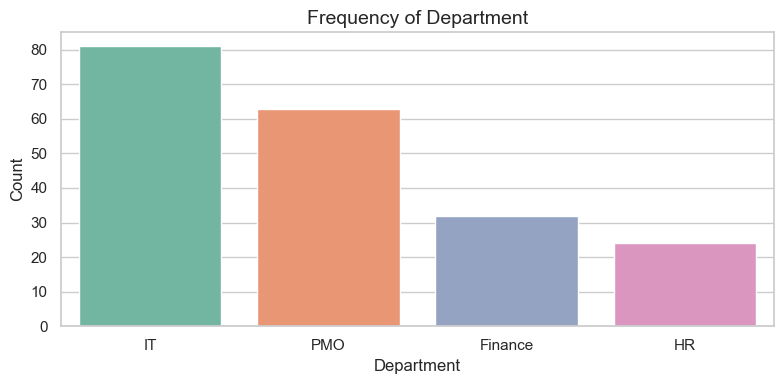

C:\Users\Almazt\AppData\Local\Temp\ipykernel_2320\1293667516.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette="Set2")


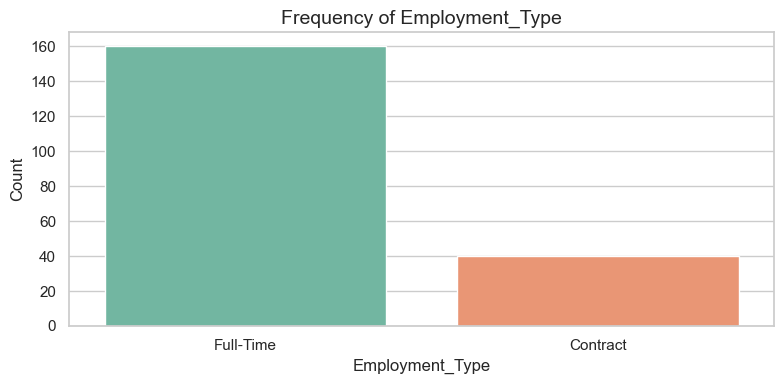

In [16]:
# Plot Bar Charts
for col in cat_cols:
    plt.figure(figsize=(8, 4))

    # value_counts().index sorts the bars from highest frequency to lowest
    order = df[col].value_counts().index

    sns.countplot(data=df, x=col, order=order, palette="Set2")

    plt.title(f"Frequency of {col}", fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel("Count", fontsize=12)
    plt.tight_layout()
    plt.show()


Key Analytical Takeaways
When looking at your histograms: Check for asymmetry (skewness). A long tail to the right means your data is right-skewed (common in financial metrics like salary or insurance claims). Look out for isolated bars at the edges, which point to potential outliers.

When looking at your bar charts: Check for extreme class imbalances. If one category holds 95% of your data, it might lack predictive power or cause issues downstream in machine learning models.

In [20]:
# from get_zipcode_correlations import zipcode_correlations

# zip_analysis_df = get_zipcode_correlations(your_dataframe)
# print(zip_analysis_df.head())